# EOS BPM simulation

This notebook is the interactive entry point for the EOS BPM simulation package. It follows the workflow of the original notebook while keeping the reusable physics code in `src/eos_bpm_sim`.

The example below simulates two electron bunches interacting with a four-piece GaP electro-optic crystal geometry. The top and bottom crystals can be rotated and delayed relative to the left and right crystals.

> **Tip:** Full camera-sized runs (`2856 x 2856`) are intentionally not used in the first cell below. Start with `512 x 512` while exploring parameters, then increase the resolution for production calculations.


## 1. Import the package

When this notebook is opened from the GitHub repository, the next cell finds the local `src/` directory automatically. This means you can run the notebook directly from a fresh checkout after creating the environment described in the README.


In [1]:
from pathlib import Path
import sys

# Find the repository root so the notebook works without installing the package
# into site-packages. The recommended setup is still `pip install -e .`.
candidates = [Path.cwd(), *Path.cwd().parents]
repo_root = next(
    p for p in candidates
    if (p / "src" / "eos_bpm_sim" / "__init__.py").exists()
)
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt

from eos_bpm_sim import (
    build_crystal_geometry,
    plot_crystal_geometry,
    simulate_eos_2b_finite,
)

print(f"Using package from: {src_path}")


Using package from: /Users/elenaros/Documents/WARG/Code/Optics/EOS_BPM/eos_bpm_sim_repo/src


## 2. Set simulation parameters

The parameters below are grouped roughly the same way as in the original notebook. Lengths such as bunch positions, crystal thickness, and laser wavelength use SI units unless the parameter name/documentation says otherwise. `Ri` and `Ro` are retained in **mm** to match the original simulation interface.


In [19]:
# -----------------------------
# Beam / bunch parameters
# -----------------------------
c = 2.99792458e8
Q1 = 1.6e-9          # drive bunch charge (C)
Q2 = 0.0             # witness bunch charge (C)

sig_1 = 20e-6 / c  # drive bunch length -> time (s)
sig_2 = 35e-6 / c   # witness bunch length -> time (s)
delt12 = 135e-6 / c  # bunch separation (s)

# Bunch positions relative to the crystal center (m)
r01x = 1e-3
r01y = 0.0
r02x = 0.0
r02y = 0.0

time_delay = 0.5e-12      # initial timing offset (s)

# -----------------------------
# GaP / laser parameters
# -----------------------------
dcry = 100e-6          # crystal thickness (m)
theta = 5              # optical angle parameter used by the model (deg)
ax_angle = 10          # axicon angle (deg)
laser = 800e-9         # laser wavelength (m)
sig_eff_laser = 50e-15 # effective laser pulse width (s)

# -----------------------------
# Four-crystal geometry
# -----------------------------
pixelsx = 512
pixelsy = 512
Ri = 5.2               # inner radius (mm)
Ro = 13.2              # outer radius (mm)
crystal_size = 10e-3   # crystal side length (m)
inner_gap_lr = 6e-3    # left/right gap (m)
inner_gap_tb = 6e-3    # top/bottom gap (m)
delay_topbottom = True
delay_amount = 200e-15 # top/bottom timing offset (s)


## 3. Preview the four-crystal geometry

This is useful before running an expensive simulation because it makes the crystal gaps and overlap regions explicit.


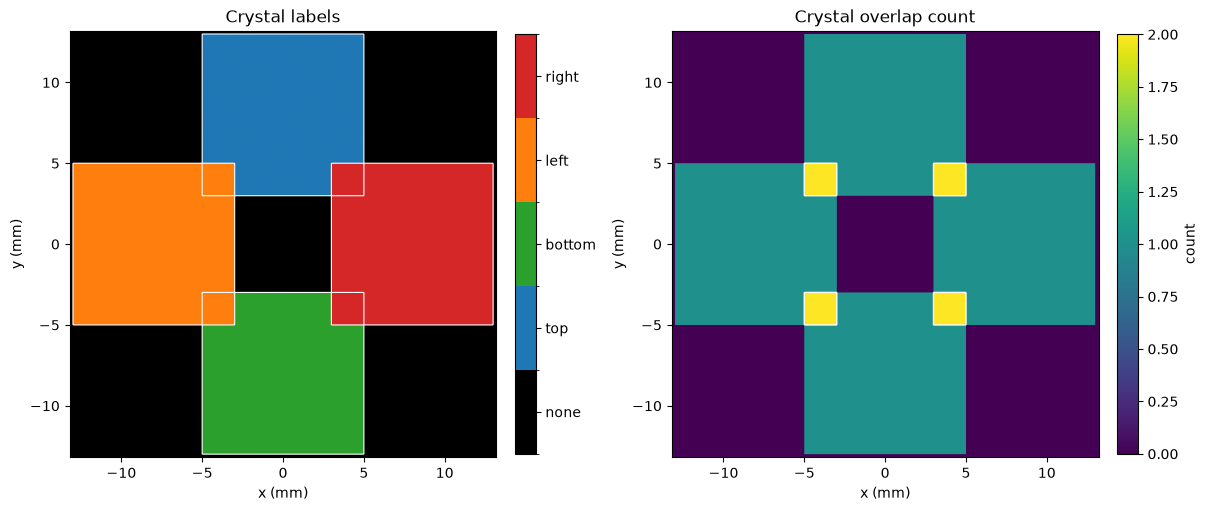

In [20]:
x_preview = np.linspace(-Ro * 1e-3, Ro * 1e-3, pixelsx)
y_preview = np.linspace(-Ro * 1e-3, Ro * 1e-3, pixelsy)
geometry = build_crystal_geometry(
    x_preview,
    y_preview,
    crystal_size=crystal_size,
    inner_gap_lr=inner_gap_lr,
    inner_gap_tb=inner_gap_tb,
)

fig, _ = plot_crystal_geometry(x_preview, y_preview, geometry)
plt.show()


## 4. Run the simulation

Set `plot=False` here so the notebook controls the formatting of the result plots below. For a quick exploratory run, keep the grid at `512 x 512`. For comparison with a camera, change both values to the desired camera resolution.


In [21]:
result = simulate_eos_2b_finite(
    r01x=r01x,
    r01y=r01y,
    r02x=r02x,
    r02y=r02y,
    time_delay=time_delay,
    Q1=Q1,
    Q2=Q2,
    sig_1=sig_1,
    sig_2=sig_2,
    delt12=delt12,
    dcry=dcry,
    theta=theta,
    ax_angle=ax_angle,
    pixelsx=pixelsx,
    pixelsy=pixelsy,
    Ri=Ri,
    Ro=Ro,
    laser=laser,
    sig_eff_laser=sig_eff_laser,
    crystal_size=crystal_size,
    inner_gap_lr=inner_gap_lr,
    inner_gap_tb=inner_gap_tb,
    delay_topbottom=delay_topbottom,
    delay_amount=delay_amount,
    plot=False,
)

intensity = result.intensity
gamma = result.gamma
time_map = result.time_map
x = result.x
y = result.y

print(f"Grid: {pixelsx} x {pixelsy}")
print(f"Pixel size x: {x[1] - x[0]:.3e} m")
print(f"Pixel size y: {y[1] - y[0]:.3e} m")
print(f"Maximum transmission: {intensity.max() * 100:.3f} %")
print(f"Gamma range: {gamma.min():.3e} to {gamma.max():.3e} rad")


Grid: 512 x 512
Pixel size x: 5.166e-05 m
Pixel size y: 5.166e-05 m
Maximum transmission: 3.032 %
Gamma range: -4.765e-02 to 3.500e-01 rad


## 5. Plot the simulated intensity and phase shift

These are the two primary 2-D outputs used in the original workflow.


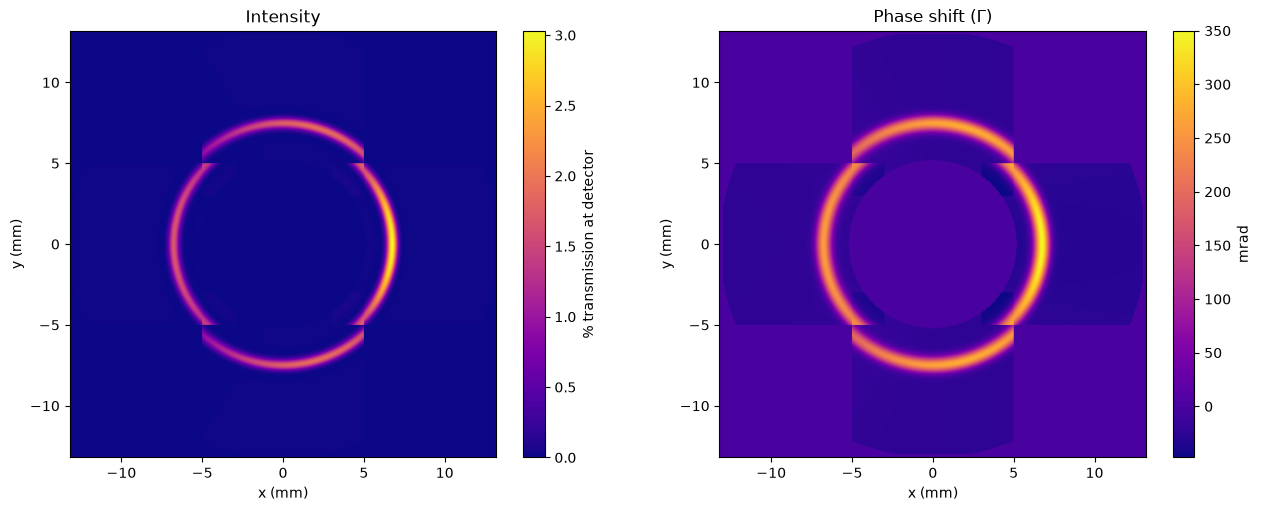

In [22]:
extent = [x.min() * 1e3, x.max() * 1e3, y.min() * 1e3, y.max() * 1e3]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

im0 = axes[0].imshow(
    intensity * 100,
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="plasma",
)
axes[0].set_title("Intensity")
axes[0].set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")
fig.colorbar(im0, ax=axes[0], label="% transmission at detector")

im1 = axes[1].imshow(
    gamma * 1e3,
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="plasma",
)
axes[1].set_title(r"Phase shift ($\Gamma$)")
axes[1].set_xlabel("x (mm)")
axes[1].set_ylabel("y (mm)")
fig.colorbar(im1, ax=axes[1], label="mrad")

plt.show()


## 6. Inspect a 1-D slice

A center-line slice is often useful for comparing the simulated response with a measured camera profile.


In [ ]:
cy = len(y) // 2

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.plot(x * 1e3, intensity[cy] * 100)
ax.set_xlabel("x (mm)")
ax.set_ylabel("% transmission")
ax.set_title("Center-row intensity")
ax.grid(True, alpha=0.25)
plt.show()


## 7. Vary the timing delay

The simulation can be rerun with a different initial timing offset. The following example changes only `time_delay`; the same bunch and crystal configuration is otherwise retained.


In [ ]:
# Example: rerun at a different timing offset
scan_time_delay = 100e-15

result_shifted = simulate_eos_2b_finite(
    r01x=r01x, r01y=r01y,
    r02x=r02x, r02y=r02y,
    time_delay=scan_time_delay,
    Q1=Q1, Q2=Q2,
    sig_1=sig_1, sig_2=sig_2, delt12=delt12,
    dcry=dcry, theta=theta, ax_angle=ax_angle,
    pixelsx=pixelsx, pixelsy=pixelsy,
    Ri=Ri, Ro=Ro, laser=laser, sig_eff_laser=sig_eff_laser,
    crystal_size=crystal_size,
    inner_gap_lr=inner_gap_lr, inner_gap_tb=inner_gap_tb,
    delay_topbottom=delay_topbottom,
    delay_amount=delay_amount,
    plot=False,
)

plt.figure(figsize=(7, 4.5), constrained_layout=True)
plt.imshow(
    result_shifted.intensity * 100,
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="plasma",
)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title(f"Intensity at time delay = {scan_time_delay * 1e15:.0f} fs")
plt.colorbar(label="% transmission")
plt.show()


## 8. Legacy API compatibility

For code that still expects the original tuple-style return value, the refactored package supports:

```python
intensity, gamma, time_map = result
```

New code can use named attributes (`result.intensity`, `result.gamma`, and so on), which makes the outputs easier to understand.


In [ ]:
intensity_legacy, gamma_legacy, time_legacy = result
print(np.allclose(intensity_legacy, result.intensity))
print(np.allclose(gamma_legacy, result.gamma))
print(np.allclose(time_legacy, result.time_map))


## Notes for larger runs

- Increase `pixelsx` and `pixelsy` only after the smaller run is working.
- A `2856 x 2856` simulation creates several large 2-D arrays and can require substantial memory.
- The package is designed so that the notebook is primarily for interactive exploration; reusable functions live in `src/eos_bpm_sim/core.py`.
- The separate `notebooks/EOS_BPM_Sim_3D_geom_2_reference.ipynb` file retains the cleaned original notebook for comparison and provenance.
